In [1]:
import numpy as np
import pandas as pd
import pvlib
import yaml
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().parent
zone = "centro_sud"
year = 2020

weather = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "weather" / zone / f"weather_{year}.csv",
    index_col=0,
    parse_dates=True,
)
weather.head()

weather = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "weather" / zone / f"weather_{year}.csv",
    index_col=0,
    parse_dates=True,
)
weather.index = pd.to_datetime(weather.index, utc=True).tz_convert("Europe/Rome")
weather.head()

,temp_c,ghi_wm2,bhi_wm2,pressure_pa,wind_speed_ms
valid_time,,,,,
2020-01-01 00:00:00+01:00,4.798675,0.0,0.0,100717.984,2.741750
2020-01-01 00:15:00+01:00,4.770386,0.0,0.0,100718.590,2.746909
2020-01-01 00:30:00+01:00,4.742096,0.0,0.0,100719.200,2.752067
2020-01-01 00:45:00+01:00,4.713806,0.0,0.0,100719.810,2.757226
2020-01-01 01:00:00+01:00,4.685516,0.0,0.0,100720.420,2.762384


In [3]:
with open(PROJECT_ROOT / "config.yaml") as f:
    config = yaml.safe_load(f)

cities = config["zones"][zone]["cities"]
lat = np.mean([c["lat"] for c in cities])
lon = np.mean([c["lon"] for c in cities])
lat, lon

(np.float64(42.08), np.float64(13.342500000000001))

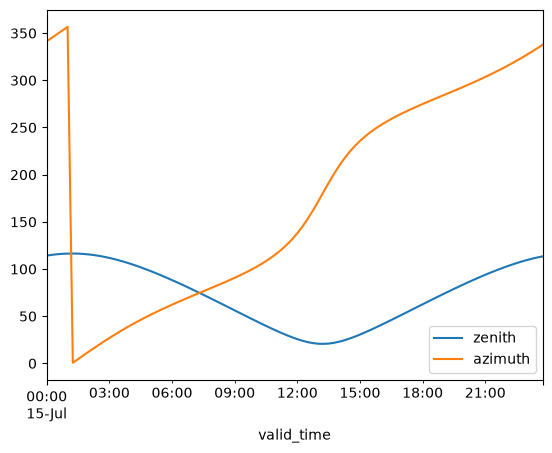

In [4]:
solpos = pvlib.solarposition.get_solarposition(
    time=weather.index,
    latitude=lat,
    longitude=lon,
)
solpos[["zenith", "azimuth"]].loc[f"{year}-07-15"].plot()
plt.show()

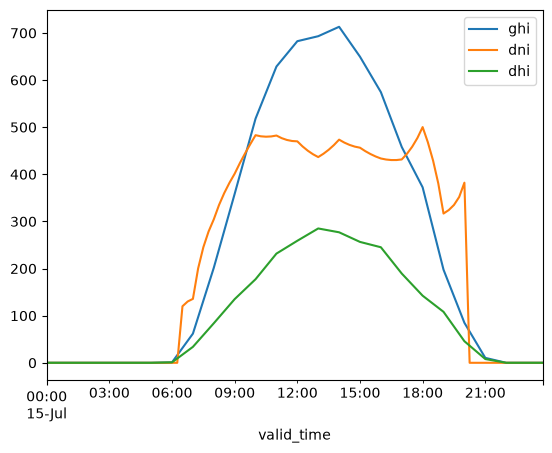

In [5]:
zenith_rad = np.radians(solpos["zenith"])
cos_zenith = np.cos(zenith_rad)

bhi = weather["bhi_wm2"]
ghi = weather["ghi_wm2"]

dni = bhi / cos_zenith
dni = dni.where(solpos["zenith"] < 85, 0.0).clip(upper=1000)
dhi = (ghi - bhi).clip(lower=0)

irradiance = pd.DataFrame({"ghi": ghi, "dni": dni, "dhi": dhi}, index=weather.index)
irradiance.loc[f"{year}-07-15"].plot()
plt.show()

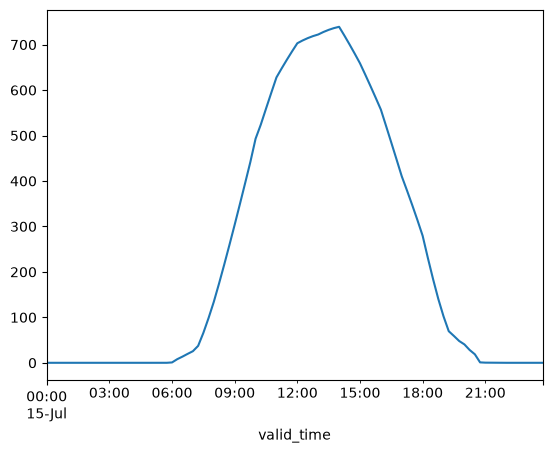

In [6]:
dni_extra = pvlib.irradiance.get_extra_radiation(weather.index)
airmass = pvlib.atmosphere.get_relative_airmass(solpos["zenith"])

poa = pvlib.irradiance.get_total_irradiance(
    surface_tilt=lat,
    surface_azimuth=180,
    solar_zenith=solpos["zenith"],
    solar_azimuth=solpos["azimuth"],
    dni=dni,
    ghi=ghi,
    dhi=dhi,
    dni_extra=dni_extra,
    airmass=airmass,
    model="perez",
)
poa["poa_global"].loc[f"{year}-07-15"].plot()
plt.show()